# Part II Evaluations (+ F: method comparison + H)

# Further evaluations 
**Responsible:** 

3.6.1 Settings and Protocol _(Joao, F)_

3.6.2 Base Heuristics _(Joao, A)_

3.6.3 Batch Allocation _(Cam, B)_

3.6.4 Kunkler Formalization _(Thomas, C)_

3.6.5 Park Formalization _(Joao, C)_

Placeholder
...

## RL policy evaluation
**Responsible:** _(Aldo Patrone)_

The paper-faithful MaskablePPO policy is evaluated in the discrete-event environment it is trained in (state 2R+A with per-activity queue counts, (r,a) action space with masking, cycle-time reward) against baselines that make the same (r,a) decisions: random, round-robin, shortest-queue, most-experienced.

The cell below shows the auxiliary numpy REINFORCE comparison. The primary verdict (results/ppo_comparison.csv, from scripts/train_ppo.py) follows.

          method  cycle_time_h  load_gini  combined
          random          0.98      0.471     0.821
     round-robin          1.12      0.477     0.886
  shortest-queue          1.07      0.486     0.872
most-experienced          1.16      0.591     1.000
  RL (REINFORCE)          0.91      0.542     0.851


saved ../results/allocation_comparison.png


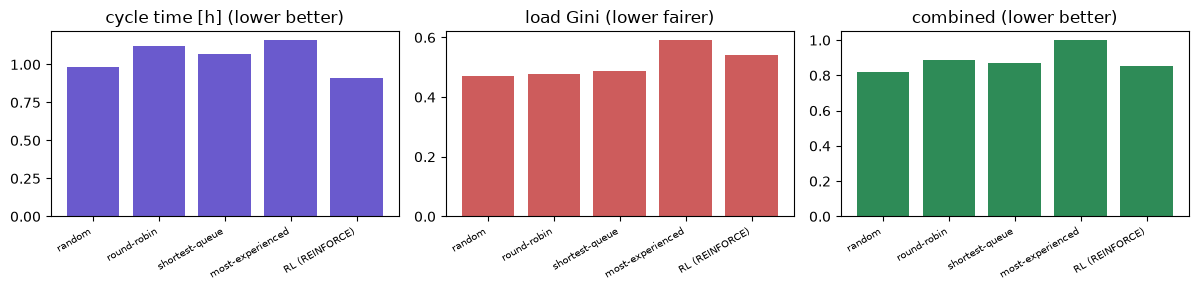

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
cmp = pd.read_csv('../results/allocation_comparison.csv')
print(cmp.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].bar(cmp['method'], cmp['cycle_time_h'], color='slateblue')
axes[0].set_title('cycle time [h] (lower better)')
axes[1].bar(cmp['method'], cmp['load_gini'], color='indianred')
axes[1].set_title('load Gini (lower fairer)')
axes[2].bar(cmp['method'], cmp['combined'], color='seagreen')
axes[2].set_title('combined (lower better)')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_ha('right'); lbl.set_fontsize(7)
fig.tight_layout(); fig.savefig('../results/allocation_comparison.png', dpi=120)
print('saved ../results/allocation_comparison.png')

## RL policy: paper-faithful evaluation
**Responsible:** _(Aldo Patrone)_

The MaskablePPO policy is evaluated in the environment it is trained in (state 2R+A with per-activity queue counts, (r,a) action space with masking, cycle-time reward) against baselines making the same (r,a) decisions, scored on mean cycle time and load fairness (results/ppo_comparison.csv).

Honest finding: even with the full paper MDP the learned policy does not beat the simple heuristics. Cycle time is nearly flat across methods (4.5 to 4.9 h), so allocation barely moves it. Shortest-queue is best on fairness (Gini 0.158) and the learned policy (0.424) does not improve on it. Most-experienced gives the lowest cycle time (4.46 h) by concentrating skilled work. The reason is structural: shortest-queue is near-optimal for load-balancing fairness, and cycle time here is dominated by arrivals and processing times rather than the eligible-resource choice.

Integrated deployment: the policy also plugs into SimulationEngineCore via optimization.ppo_agent.PPOAllocation (per-task reduction, queue term reduced at inference). A full integrated multi-seed rerun needs the engine XES reader and the processing-time model together with sb3 in one environment. The integrated baseline comparison is task F (3.6.7).

In [ ]:
import pandas as pd, matplotlib.pyplot as plt

# Paper-faithful MaskablePPO evaluation (state 2R+A, (r,a) action space, cycle-time reward),
# produced by scripts/train_ppo.py. Primary Task-D result. Labels are authoritative (no rename).
df = pd.read_csv('../results/ppo_comparison.csv')
order = ['random', 'round-robin', 'shortest-queue', 'most-experienced', 'PPO (MaskablePPO)']
df = df.set_index('method').reindex(order).reset_index()
print(df[['method', 'cycle_time_h', 'load_gini']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].bar(df['method'], df['cycle_time_h'], color='slateblue')
axes[0].set_title('cycle time [h] (lower better)')
axes[1].bar(df['method'], df['load_gini'], color='indianred')
axes[1].set_title('load Gini (lower fairer)')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_ha('right'); lbl.set_fontsize(7)
fig.tight_layout(); fig.savefig('../results/allocation_sim_comparison.png', dpi=120)
print('saved ../results/allocation_sim_comparison.png')

# Further evaluations 
**Responsible:** 

3.6.7 Cross-Method Synthesis _(Joao, F)_

3.6.8 Slide-23 Question _(Cam, H)_

Placeholder
...